# --- plotting the price change chart

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.2)

In [16]:
# ============================
# 1. LOAD EXCEL
# ============================

path = "data/processed/BTC_USDT_1h_macro_draft.xlsx"
df = pd.read_excel(path)

# Переконайся, що timestamp у форматі datetime
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# ============================
# 2. DROP FIRST 348 ROWS (due to NAN)
# ============================

df = df.iloc[348:].reset_index(drop=True)


Train: (42800, 105)
Val: (5350, 105)
Test: (5351, 105)


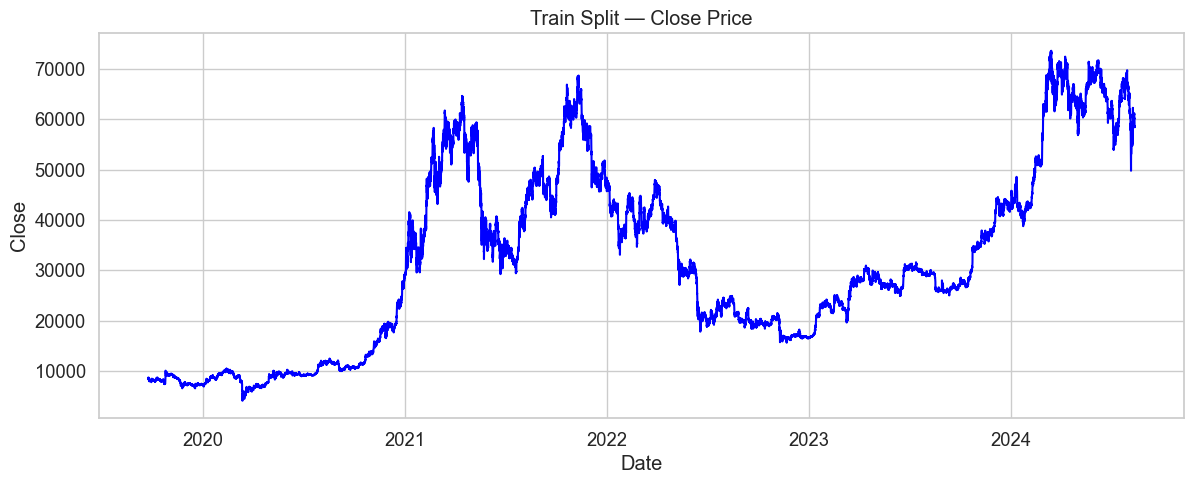

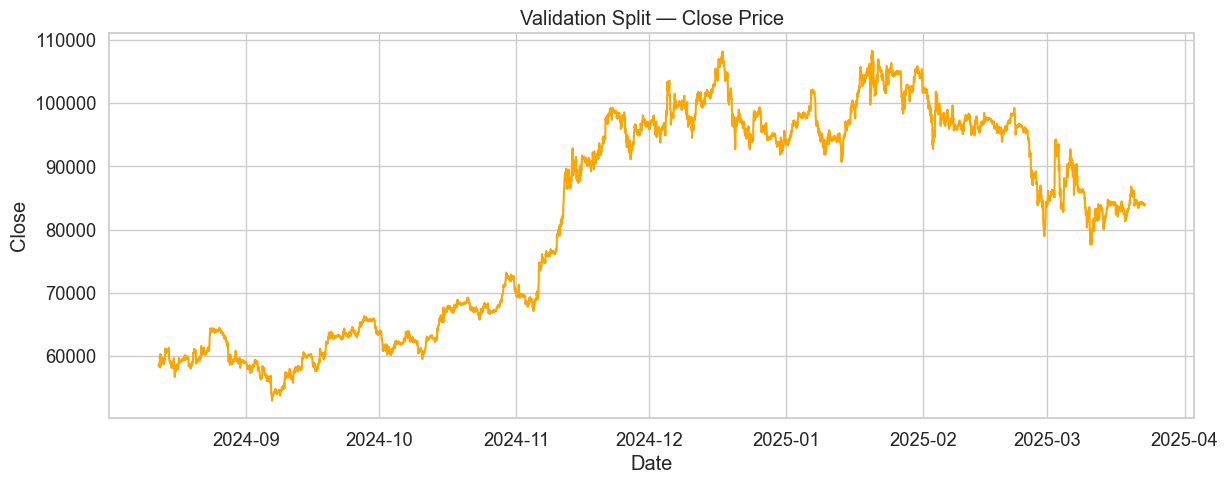

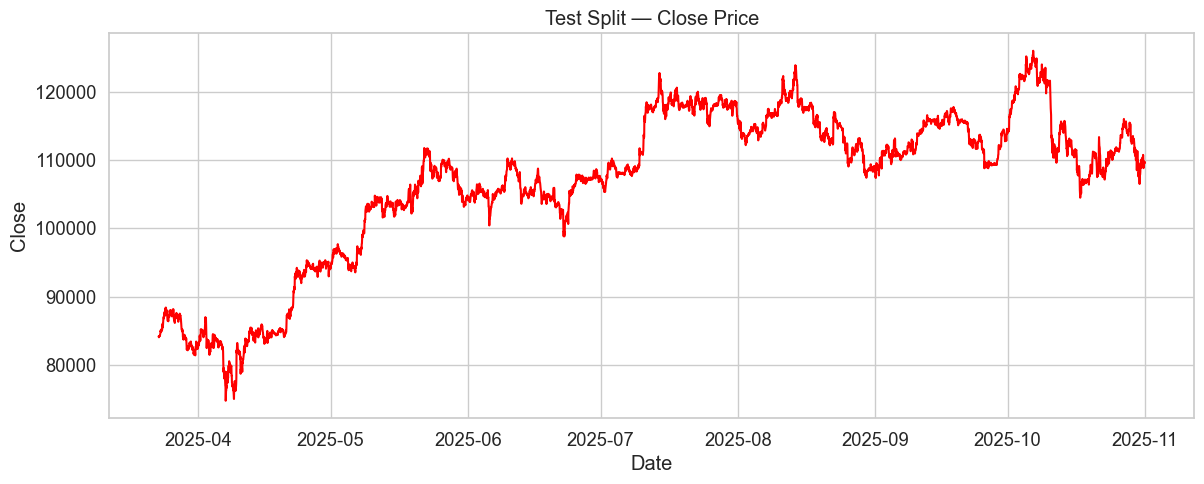

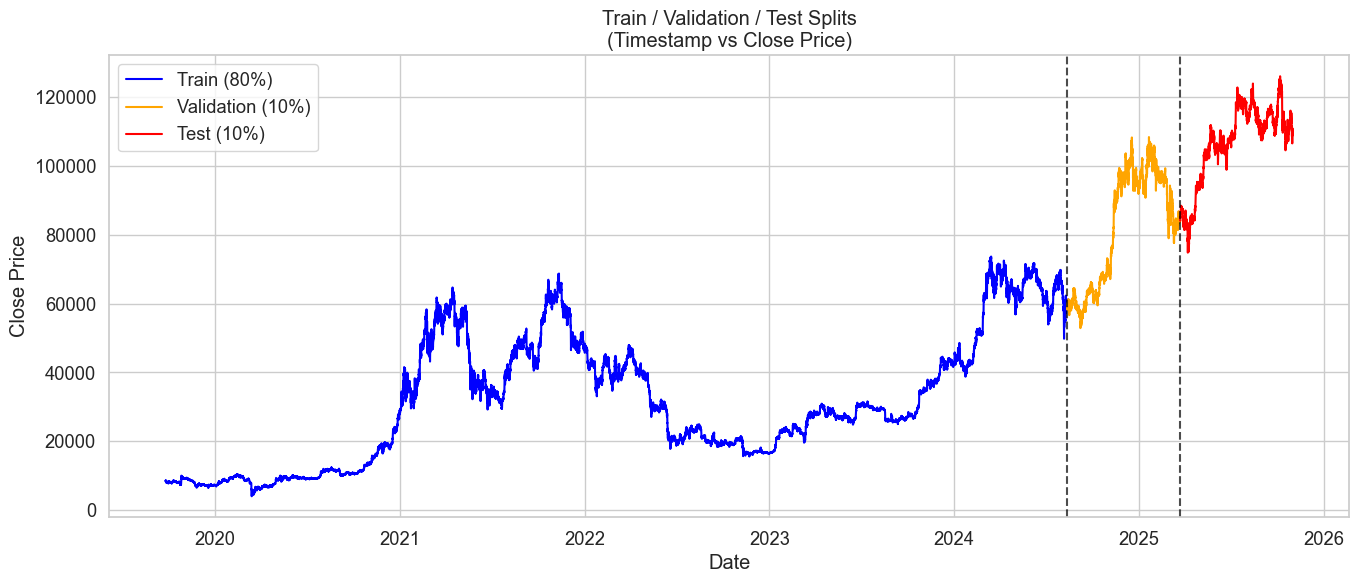

In [ ]:

# ============================
# 3. TRAIN/VAL/TEST SPLIT (80/10/10)
# ============================

n = len(df)
train_end = int(n * 0.8)
val_end = int(n * 0.9)

df_train = df.iloc[:train_end]
df_val   = df.iloc[train_end:val_end]
df_test  = df.iloc[val_end:]

print("Train:", df_train.shape)
print("Val:", df_val.shape)
print("Test:", df_test.shape)

# ============================
# 4. PLOT EACH PART SEPARATELY
# ============================

plt.figure(figsize=(14, 5))
plt.plot(df_train["timestamp"], df_train["close"], label="Train", color="blue")
plt.title("Train Split — Close Price")
plt.xlabel("Date")
plt.ylabel("Close")
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(df_val["timestamp"], df_val["close"], label="Validation", color="orange")
plt.title("Validation Split — Close Price")
plt.xlabel("Date")
plt.ylabel("Close")
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(df_test["timestamp"], df_test["close"], label="Test", color="red")
plt.title("Test Split — Close Price")
plt.xlabel("Date")
plt.ylabel("Close")
plt.grid(True)
plt.show()

# ============================
# 5. ONE COMBINED GRAPH (BEST FOR DIPLOMA)
# ============================

plt.figure(figsize=(16, 6))

plt.plot(df_train["timestamp"], df_train["close"], color="blue", label="Train (80%)")
plt.plot(df_val["timestamp"], df_val["close"], color="orange", label="Validation (10%)")
plt.plot(df_test["timestamp"], df_test["close"], color="red", label="Test (10%)")

# Виділяємо вертикальними лініями межі
plt.axvline(df_val["timestamp"].iloc[0], color="black", linestyle="--", alpha=0.7)
plt.axvline(df_test["timestamp"].iloc[0], color="black", linestyle="--", alpha=0.7)

plt.title("Train / Validation / Test Splits\n(Timestamp vs Close Price)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)

plt.show()


In [ ]:
KD = 2       # SL
KU = 6       # TP
H = 336      # HOLD

pubs = []    # Peak Up Before Stop
n = len(df)

for i in range(n):
    entry = df["close"].iloc[i]
    atr = df["atr_200"].iloc[i]

    stop_level = entry - KD * atr

    max_up = 0

    for j in range(i+1, min(i+H, n)):

        high_j = df["high"].iloc[j]
        low_j  = df["low"].iloc[j]

        # 1) Stop triggered → finishing
        if low_j <= stop_level:
            break

        # 2) Remember the maximum before the stop triggers
        max_up = max(max_up, high_j - entry)


    pubs.append(max_up / atr)


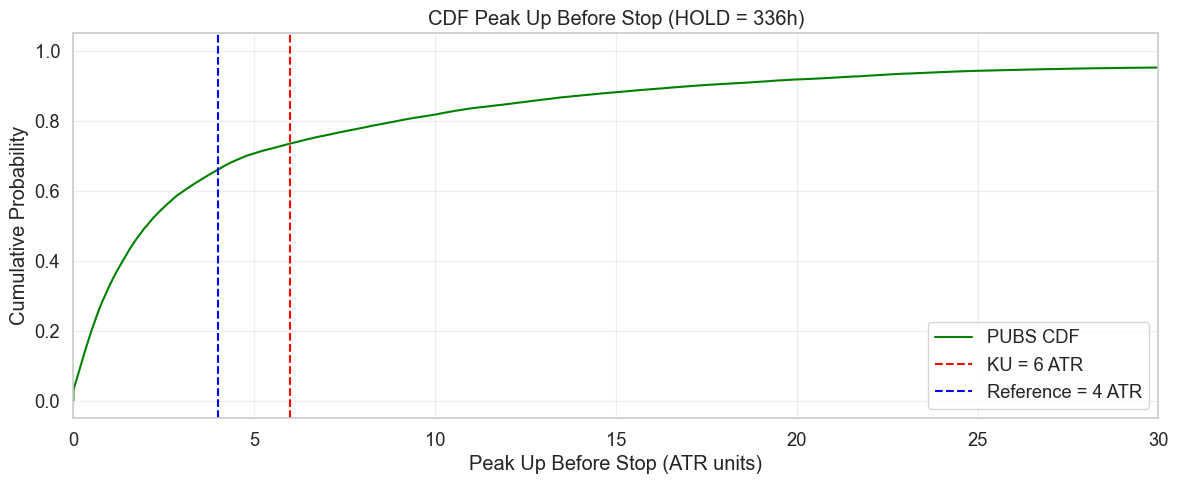

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

KU = 6
KU2 = 4   # comparison level
H = 336

# pubs — the list of Peak Up Before Stop values (in ATR)
pubs_arr = np.array(pubs)
pubs_arr = pubs_arr[~np.isnan(pubs_arr)]
pubs_sorted = np.sort(pubs_arr)
cdf = np.arange(1, len(pubs_sorted) + 1) / len(pubs_sorted)

plt.figure(figsize=(14, 5))

plt.plot(pubs_sorted, cdf, label="PUBS CDF", color="green")

# Vertical lines
plt.axvline(KU, color="red", linestyle="--", label="KU = 6 ATR")
plt.axvline(KU2, color="blue", linestyle="--", label="Reference = 4 ATR")

plt.title(f"CDF Peak Up Before Stop (HOLD = {H}h)")
plt.xlabel("Peak Up Before Stop (ATR units)")
plt.ylabel("Cumulative Probability")

# Trimming the X-axis
plt.xlim(0, 30)

plt.legend()
plt.grid(alpha=0.3)
plt.show()


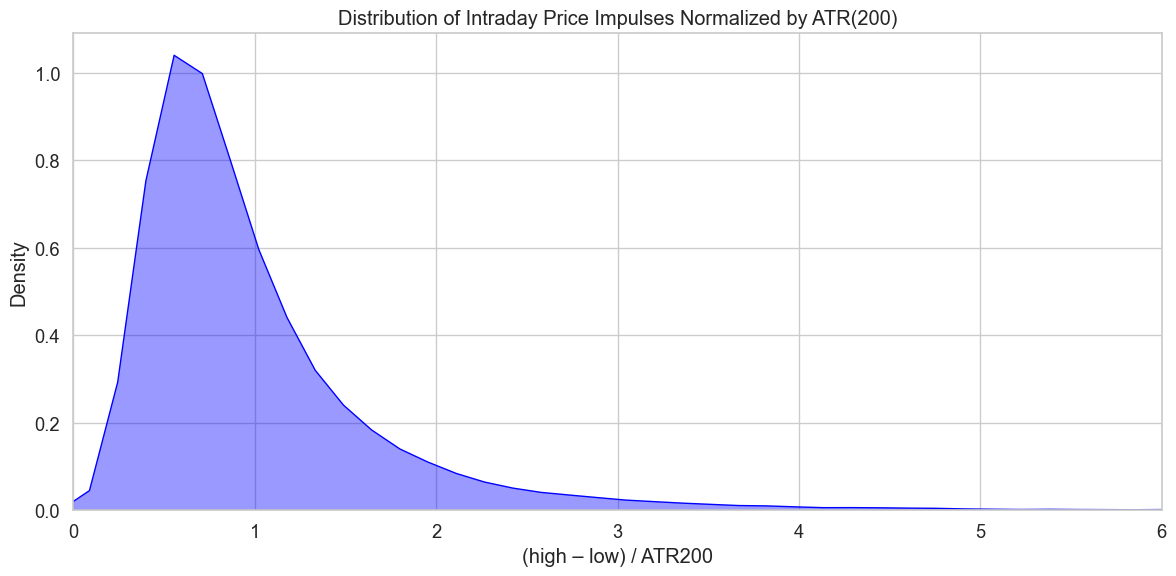

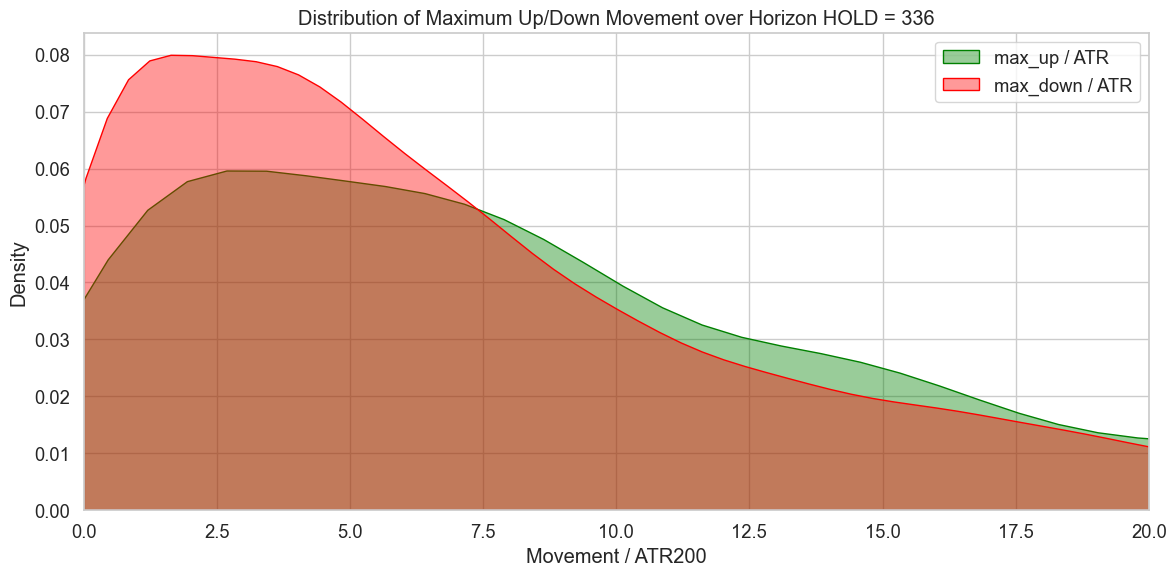

All graphs successfully generated.


In [30]:
# ================================
# 4. FIGURE 1: Δ = (high-low)/ATR200 (Impulse Distribution)
# ================================
df["impulse_atr"] = (df["high"] - df["low"]) / df["atr_200"].clip(1e-9)

plt.figure(figsize=(12, 6))
sns.kdeplot(df["impulse_atr"], fill=True, color="blue", alpha=0.4)
plt.title("Distribution of Intraday Price Impulses Normalized by ATR(200)")
plt.xlabel("(high – low) / ATR200")
plt.ylabel("Density")
plt.xlim(0, 6) 
plt.tight_layout()
plt.show()


# ================================
# 5. FIGURE 2: Max Up / Max Down per HOLD=336
# ================================
HOLD = 336

max_up = []
max_down = []

close = df["close"].values
atr200 = df["atr_200"].values

for i in range(len(df) - HOLD):
    future_window = close[i:i+HOLD]

    up = (future_window.max() - close[i]) / atr200[i]
    down = (close[i] - future_window.min()) / atr200[i]

    max_up.append(up)
    max_down.append(down)

max_df = pd.DataFrame({"max_up": max_up, "max_down": max_down})

plt.figure(figsize=(12, 6))
sns.kdeplot(max_df["max_up"], fill=True, color="green", alpha=0.4, label="max_up / ATR")
sns.kdeplot(max_df["max_down"], fill=True, color="red", alpha=0.4, label="max_down / ATR")
plt.legend()
plt.title("Distribution of Maximum Up/Down Movement over Horizon HOLD = 336")
plt.xlabel("Movement / ATR200")
plt.ylabel("Density")
plt.xlim(0, 20) 
plt.tight_layout()
plt.show()


print("All graphs successfully generated.")

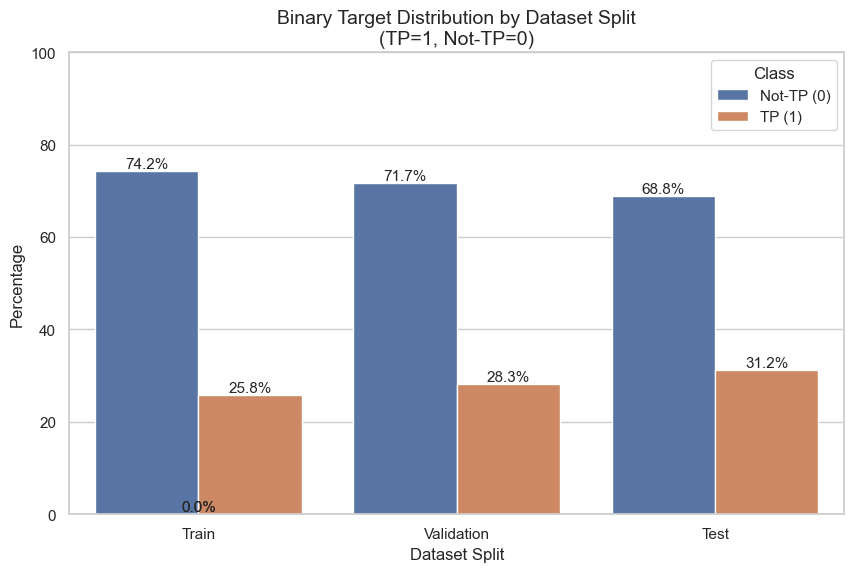

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load splits
base = "artifacts/splits/ku6.0_kd2.0_hold336"
train = pd.read_parquet(f"{base}/train.parquet")
val   = pd.read_parquet(f"{base}/val.parquet")
test  = pd.read_parquet(f"{base}/test.parquet")

# Force binarization (TP=1, Not-TP=0)
for d in (train, val, test):
    d["y_bin"] = (d["y"] == 2).astype(int)

# Prepare plotting dataframe
def prep(df, name):
    vc = df["y_bin"].value_counts(normalize=True)
    return pd.DataFrame({
        "split": name,
        "class": ["Not-TP (0)", "TP (1)"],
        "percent": [vc.get(0, 0)*100, vc.get(1, 0)*100]
    })

plot_df = pd.concat([
    prep(train, "Train"),
    prep(val, "Validation"),
    prep(test, "Test")
])

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=plot_df, x="split", y="percent", hue="class",
    palette=["#4c72b0", "#dd8452"]
)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.1f}%",
                (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom', fontsize=11)

plt.title("Binary Target Distribution by Dataset Split\n(TP=1, Not-TP=0)", fontsize=14)
plt.xlabel("Dataset Split")
plt.ylabel("Percentage")
plt.ylim(0, 100)
plt.legend(title="Class")
plt.show()


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("artifacts/trade_predictions_cat_raw.csv", parse_dates=["timestamp"])


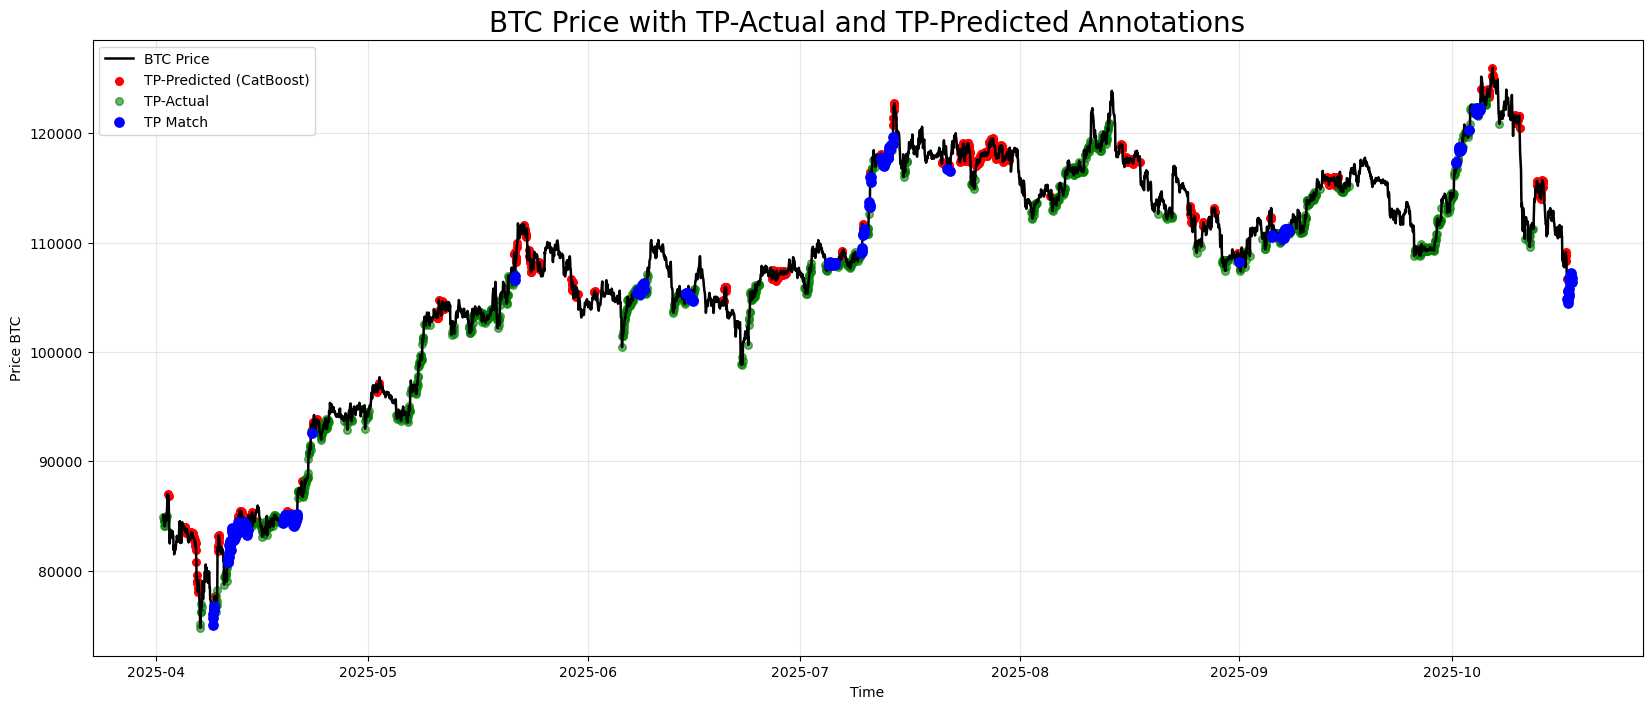

In [9]:
plt.figure(figsize=(20,8))

plt.plot(df.timestamp, df.close, label="BTC Price", color="black", linewidth=1.8)

# Прогноз моделі = TP
pred_tp = df[df.y_pred == 1]
plt.scatter(pred_tp.timestamp, pred_tp.close,
            color="red", s=30, label="TP-Predicted (CatBoost)")

# Фактичний TP
true_tp = df[df.y_true == 1]
plt.scatter(true_tp.timestamp, true_tp.close,
            color="green", s=30, alpha=0.6, label="TP-Actual")

# TP match
tp_match = df[(df.y_pred == 1) & (df.y_true == 1)]
plt.scatter(tp_match.timestamp, tp_match.close,
            color="blue", s=45, label="TP Match", zorder=3)


plt.title("BTC Price with TP-Actual and TP-Predicted Annotations", fontsize=20)
plt.xlabel("Time")
plt.ylabel("Price BTC")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


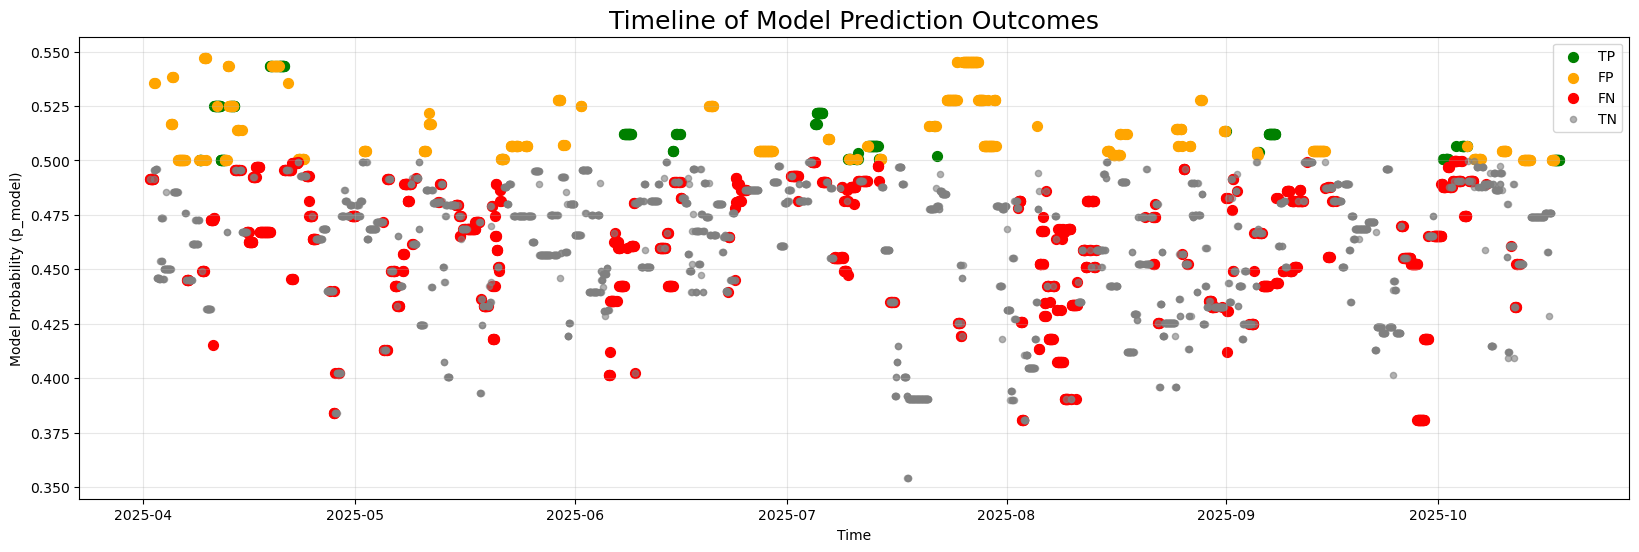

In [9]:
plt.figure(figsize=(20,6))

# True Positive
tp = df[(df.y_true == 1) & (df.y_pred == 1)]
plt.scatter(tp.timestamp, tp.p_model, color="green", label="TP", s=50)

# False Positive
fp = df[(df.y_true == 0) & (df.y_pred == 1)]
plt.scatter(fp.timestamp, fp.p_model, color="orange", label="FP", s=50)

# False Negative
fn = df[(df.y_true == 1) & (df.y_pred == 0)]
plt.scatter(fn.timestamp, fn.p_model, color="red", label="FN", s=50)

# True Negative
tn = df[(df.y_true == 0) & (df.y_pred == 0)]
plt.scatter(tn.timestamp, tn.p_model, color="gray", label="TN", s=20, alpha=0.6)

plt.title("Timeline of Model Prediction Outcomes", fontsize=18)
plt.xlabel("Time")
plt.ylabel("Model Probability (p_model)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()
